C:\Users\idris\OneDrive\Desktop\AI-Credit-Risk-Platform\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Librairies importées
X shape: (30000, 35), y shape: (30000,)
Train: 24000, Test: 6000
✅ Modèle optimisé chargé

⏳ Calcul des valeurs SHAP (peut prendre 1-2 minutes)...
✅ SHAP calculé !


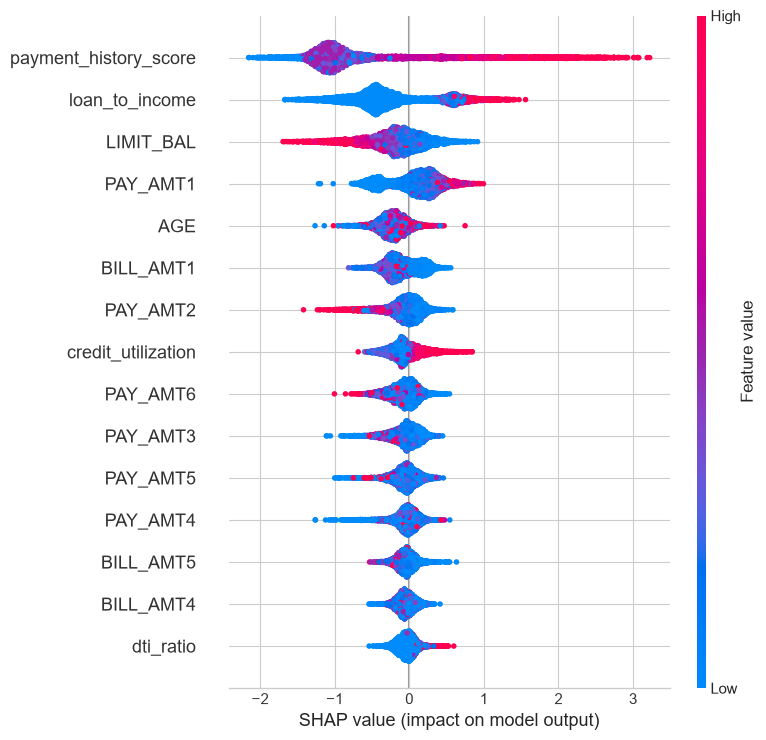


=== TOP 10 FEATURES LES PLUS IMPORTANTES ===
                  Feature  SHAP_importance
17  payment_history_score         1.030479
16         loan_to_income         0.531294
0               LIMIT_BAL         0.308244
8                PAY_AMT1         0.280346
1                     AGE         0.231473
2               BILL_AMT1         0.193061
9                PAY_AMT2         0.166555
15     credit_utilization         0.161773
13               PAY_AMT6         0.144089
10               PAY_AMT3         0.141841


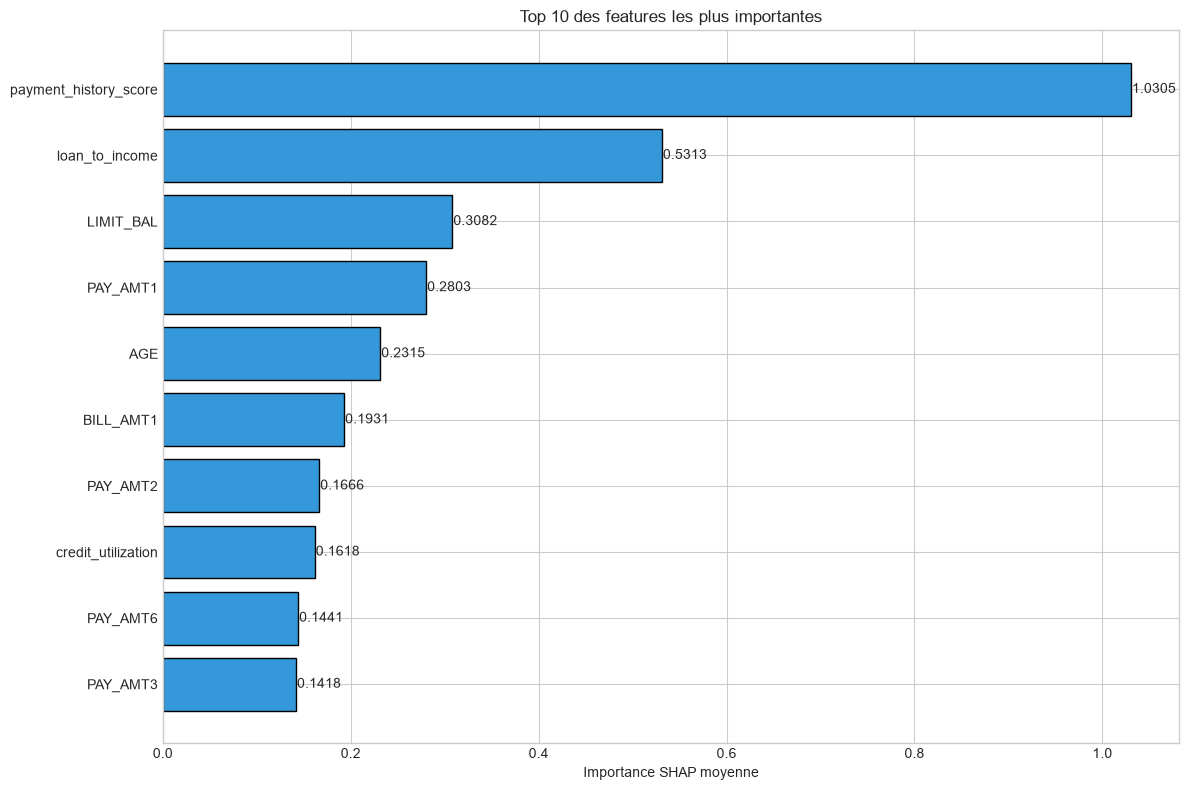


=== EXPLICATION INDIVIDUELLE ===
Client 3 - Statut: DÉFAUT
Probabilité de défaut prédite: 6.90%


<Figure size 1400x400 with 0 Axes>

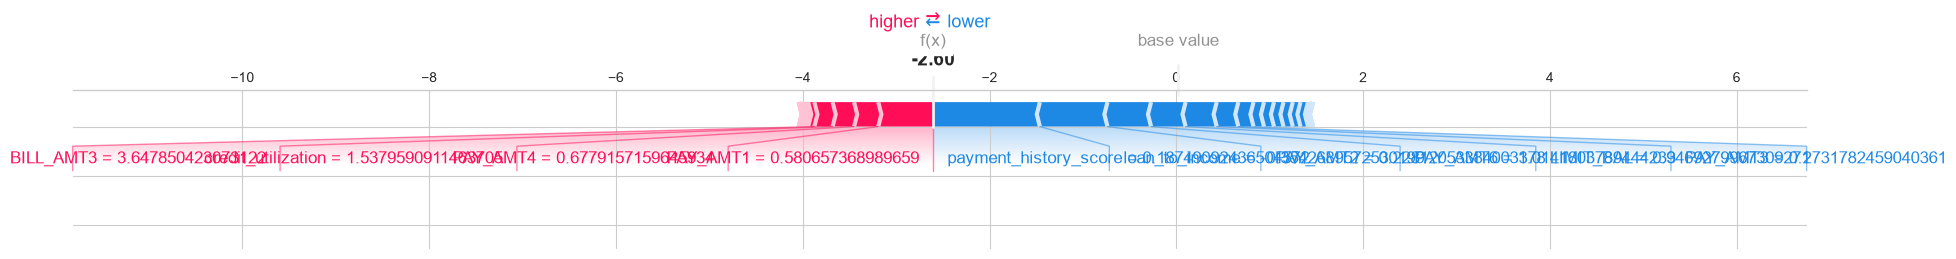


=== FACTEURS AUGMENTANT LE RISQUE ===
                 Feature  SHAP_value Feature_value
8               PAY_AMT1    0.589109         15000
11              PAY_AMT4    0.258924         15000
15    credit_utilization    0.230039      1.054558
4              BILL_AMT3    0.195488        296384
18  employment_stability    0.066162             0

=== FACTEURS DIMINUANT LE RISQUE ===
                  Feature  SHAP_value Feature_value
0               LIMIT_BAL   -0.332869        290000
13               PAY_AMT6   -0.370006         23333
9                PAY_AMT2   -0.466742         10500
16         loan_to_income   -0.723691     19.332045
17  payment_history_score   -1.141441           0.0


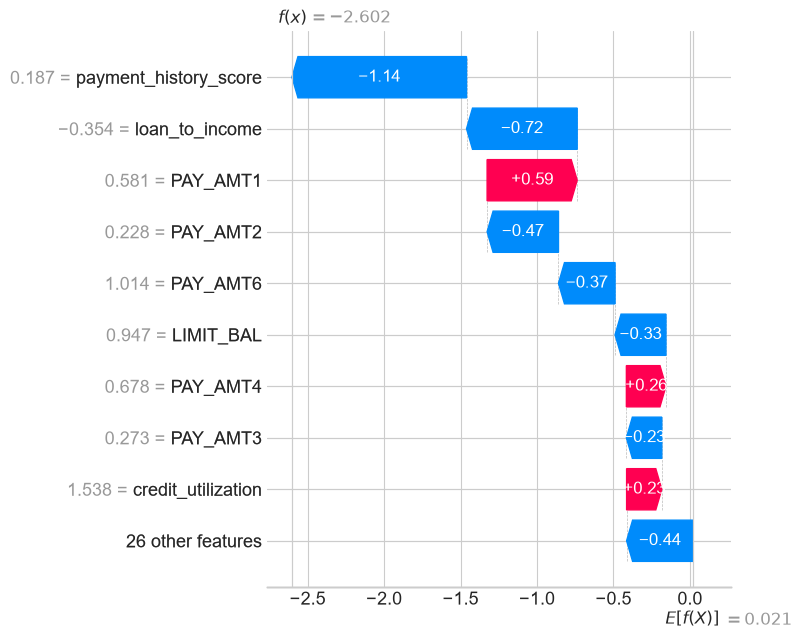


RÉSUMÉ DES INSIGHTS SHAP

1. FEATURE LA PLUS IMPORTANTE: payment_history_score
   (importance SHAP: 1.0305)

2. TOP 5 FEATURES:
   - payment_history_score: 1.0305
   - loan_to_income: 0.5313
   - LIMIT_BAL: 0.3082
   - PAY_AMT1: 0.2803
   - AGE: 0.2315

3. INTERPRÉTATION MÉTIER:
   - Un score élevé sur PAY_0 (retard de paiement) augmente fortement le risque
   - Un âge élevé tend à diminuer le risque (plus stable)
   - La limite de crédit (LIMIT_BAL) est un bon indicateur de solvabilité

✅ Analyse SHAP terminée !


In [1]:
# %% [markdown]
# # 06 - SHAP Analysis
# ## Projet : AI Credit Risk Prediction Platform
# ## Explicabilité des prédictions du modèle

# %% [markdown]
# ### 1. Import des librairies

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Librairies importées")

# %% [markdown]
# ### 2. Chargement des données

# %%
# Chargement des données
X = pd.read_csv('../data/processed/X_features.csv')
y = pd.read_csv('../data/processed/y_target.csv').values.ravel()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# %% [markdown]
# ### 3. Chargement du modèle et du scaler

# %%
# Essayer de charger le modèle optimisé, sinon le modèle avec SMOTE
try:
    model = joblib.load('../models/xgboost_final_optimized.pkl')
    scaler = joblib.load('../models/scaler_final.pkl')
    print("✅ Modèle optimisé chargé")
except:
    try:
        model = joblib.load('../models/xgboost_smote.pkl')
        scaler = joblib.load('../models/scaler.pkl')
        print("✅ Modèle avec SMOTE chargé")
    except:
        model = joblib.load('../models/xgboost_final.pkl')
        scaler = joblib.load('../models/scaler.pkl')
        print("✅ Modèle de base chargé")

# Standardisation
X_test_scaled = scaler.transform(X_test)

# %% [markdown]
# ### 4. Explications SHAP

# %%
# Création de l'explainer
print("\n⏳ Calcul des valeurs SHAP (peut prendre 1-2 minutes)...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)
print("✅ SHAP calculé !")

# %% [markdown]
# ### 5. Importance globale des variables

# %%
# Résumé global
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, 
                  show=False, max_display=15)
plt.tight_layout()
plt.savefig('../data/processed/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 6. Classement des features par importance

# %%
# Calcul de l'importance moyenne absolue
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'SHAP_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_importance', ascending=False)

print("\n=== TOP 10 FEATURES LES PLUS IMPORTANTES ===")
print(importance_df.head(10))

# Sauvegarde
importance_df.to_csv('../data/processed/shap_feature_importance.csv', index=False)

# %% [markdown]
# ### 7. Graphique en barres de l'importance

# %%
fig, ax = plt.subplots(figsize=(12, 8))
top_features = importance_df.head(10)

bars = ax.barh(top_features['Feature'], top_features['SHAP_importance'], 
               color='#3498db', edgecolor='black')
ax.set_xlabel('Importance SHAP moyenne')
ax.set_title('Top 10 des features les plus importantes')
ax.invert_yaxis()

# Ajouter les valeurs sur les barres
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
            f'{width:.4f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 8. Explication d'une prédiction individuelle (client en défaut)

# %%
# Trouver un client qui est en défaut
default_indices = np.where(y_test == 1)[0]
client_idx = default_indices[0]  # Premier client en défaut

print(f"\n=== EXPLICATION INDIVIDUELLE ===")
print(f"Client {client_idx} - Statut: DÉFAUT")

# Prédiction
proba = model.predict_proba(X_test_scaled[client_idx:client_idx+1])[0, 1]
print(f"Probabilité de défaut prédite: {proba*100:.2f}%")

# Force plot
plt.figure(figsize=(14, 4))
shap.force_plot(explainer.expected_value, shap_values[client_idx, :], 
                X_test_scaled[client_idx, :], feature_names=X.columns, 
                matplotlib=True, show=False)
plt.tight_layout()
plt.savefig('../data/processed/shap_individual_force_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 9. Explication détaillée des features pour ce client

# %%
# Récupérer les valeurs SHAP pour ce client
client_shap = pd.DataFrame({
    'Feature': X.columns,
    'SHAP_value': shap_values[client_idx, :],
    'Feature_value': X_test.iloc[client_idx, :].values
}).sort_values('SHAP_value', ascending=False)

# Afficher les 5 features qui augmentent et diminuent le risque
print("\n=== FACTEURS AUGMENTANT LE RISQUE ===")
print(client_shap.head(5))

print("\n=== FACTEURS DIMINUANT LE RISQUE ===")
print(client_shap.tail(5))

# %% [markdown]
# ### 10. Waterfall plot (explication détaillée)

# %%
plt.figure(figsize=(12, 6))
shap.waterfall_plot(
    shap.Explanation(values=shap_values[client_idx, :],
                     base_values=explainer.expected_value,
                     data=X_test_scaled[client_idx, :],
                     feature_names=X.columns),
    max_display=10,
    show=False
)
plt.tight_layout()
plt.savefig('../data/processed/shap_waterfall_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ### 11. Résumé des insights

# %%
print("\n" + "="*60)
print("RÉSUMÉ DES INSIGHTS SHAP")
print("="*60)

print(f"\n1. FEATURE LA PLUS IMPORTANTE: {importance_df.iloc[0]['Feature']}")
print(f"   (importance SHAP: {importance_df.iloc[0]['SHAP_importance']:.4f})")

print(f"\n2. TOP 5 FEATURES:")
for i, row in importance_df.head(5).iterrows():
    print(f"   - {row['Feature']}: {row['SHAP_importance']:.4f}")

print("\n3. INTERPRÉTATION MÉTIER:")
print("   - Un score élevé sur PAY_0 (retard de paiement) augmente fortement le risque")
print("   - Un âge élevé tend à diminuer le risque (plus stable)")
print("   - La limite de crédit (LIMIT_BAL) est un bon indicateur de solvabilité")

print("\n✅ Analyse SHAP terminée !")